# Data Acquisition #
- Topic Choice: NYC 311 Service Request Patterns 
- Dataset URL: https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9/about_data 
- Project Proposal: This project will analyze New York City’s 311 Service Request data to investigate non-emergency complaint trends over time, geography, and complaint type throughout the city. The main analytical questions are: 
    - Which complaint categories are most prevalent in each borough? 
    - How do complaint volumes and types shift seasonally? 
    - Which neighborhoods exhibit the largest amounts of unresolved or slow-to-resolve requests? 
- To answer these questions, this project will apply geospatial analysis to produce heatmaps of complaint hotspots, conduct temporal analysis to investigate seasonal and weekly patterns, and compute resolution time distributions by complaint type of borough. The goal is to investigate patterns in how New Yorkers interact with city services which will reveal whether there are systemic delays in issue resolution and whether specific complaint types cluster spatially which may reflect underlying infrastructure conditions. 
- Proof of Dataset download/access: The dataset was downloaded on April 1st, it is a ~13 GB csv file containing all the data

# Data Loading #

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set path for dataset
filepath = "311_Service_Requests_from_2020_to_Present_20260401.csv"

# Use these columns for analysis
usecols = [
    'Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name', 
    'Problem (formerly Complaint Type)', 'Problem Detail (formerly Descriptor)', 
    'Location Type', 'Incident Zip', 'Borough', 'Status', 'Latitude', 'Longitude'
]

# Load data
df = pd.read_csv(filepath, usecols=usecols, low_memory=False)#, nrows=10000000)

print(f"Data loaded with shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")


Data loaded with shape: (20682653, 13)
Memory Usage: 12986.50 MB


# Data Cleaning #

In [ ]:
# Convert datetime columns in datetime objects
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

# Handle missing zip codes and make sure they're valid
df['Incident Zip'] = df['Incident Zip'].astype(str).str[:5]
df['Incident Zip'] = df['Incident Zip'].replace('nan', np.nan)

# Clean up 'Borough' column since it sometimes uses 'Unspecified'
df['Borough'] = df['Borough'].replace('Unspecified', np.nan)

# Drop columns where 'Created Date' or the problem is missing
df.dropna(subset=['Created Date', 'Problem (formerly Complaint Type)'], inplace=True)

# Remove negative resolution times (potentialy data entry errors)
df = df[(df['ResolutionTimeHours'] >= 0 | df['ResolutionTimeHours'].isna())]

# New shape and memory usage
print(f"New Data Shape: {df.shape}")
print(f"New Memory Usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

New Data Shape: (20229531, 14)
New Memory Usage: 10596.70 MB


## Feature Engineering ##

In [ ]:
# Create new column that calculates resolution time in hours
df['ResolutionTimeHours'] = (df['Closed Date'] - df['Created Date']).dt.total_seconds() / 3600

# EDA Visualizations #

In [61]:
# Set Seaborn theme
sns.set_theme(style="whitegrid")

## Top 40 Most Frequent Complaints ##

/var/folders/dr/l7061z6x155_nwbh9k4h_b4c0000gn/T/ipykernel_36721/2985315140.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topProblems.values, y=topProblems.index, palette="viridis")


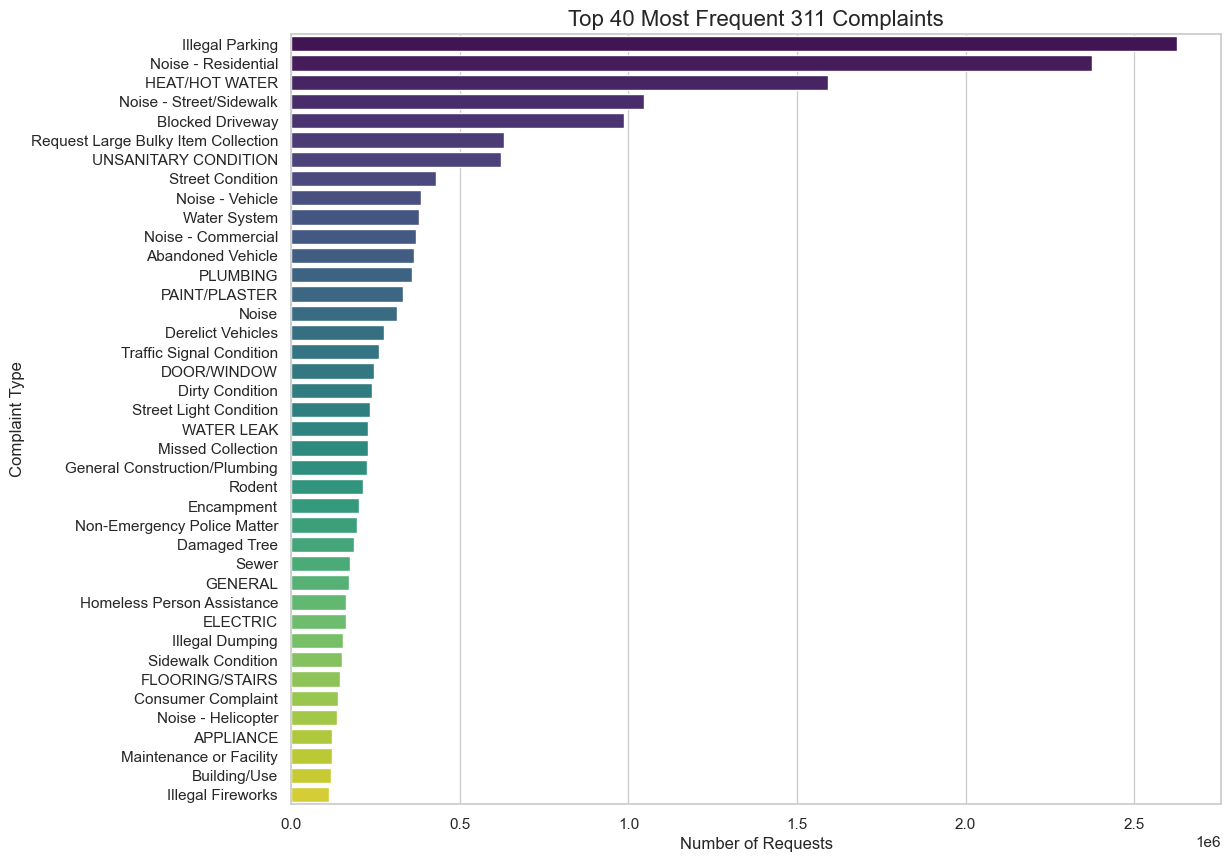

In [68]:
plt.figure(figsize=(12, 10))
topProblems = df['Problem (formerly Complaint Type)'].value_counts().head(40) 
sns.barplot(x=topProblems.values, y=topProblems.index, palette="viridis")
plt.title("Top 40 Most Frequent 311 Complaints", fontsize=16)
plt.xlabel("Number of Requests", fontsize=12)
plt.ylabel("Complaint Type", fontsize=12)
plt.show()

- Caption

## Complaints Distribution by Borough ##

/var/folders/dr/l7061z6x155_nwbh9k4h_b4c0000gn/T/ipykernel_36721/3536105001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=boroughCounts, x='count', y='Borough', palette="magma")


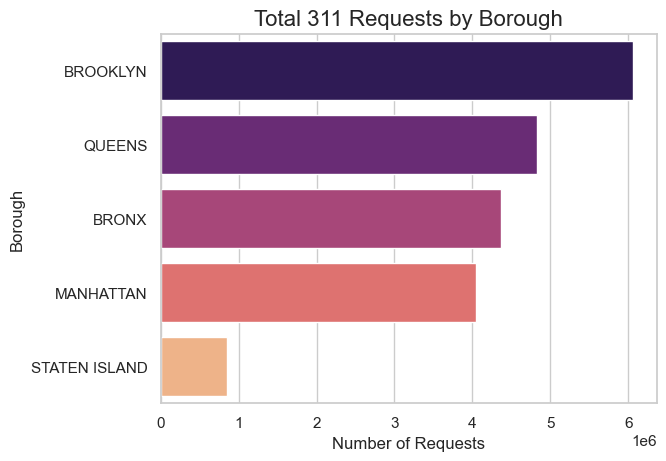

In [69]:
boroughCounts = df['Borough'].value_counts().reset_index()
sns.barplot(data=boroughCounts, x='count', y='Borough', palette="magma")
plt.title("Total 311 Requests by Borough", fontsize=16)
plt.xlabel("Number of Requests", fontsize=12)
plt.ylabel("Borough", fontsize=12)
plt.show()

- Caption

## Trend of Complaints Over Time (Monthly) ##

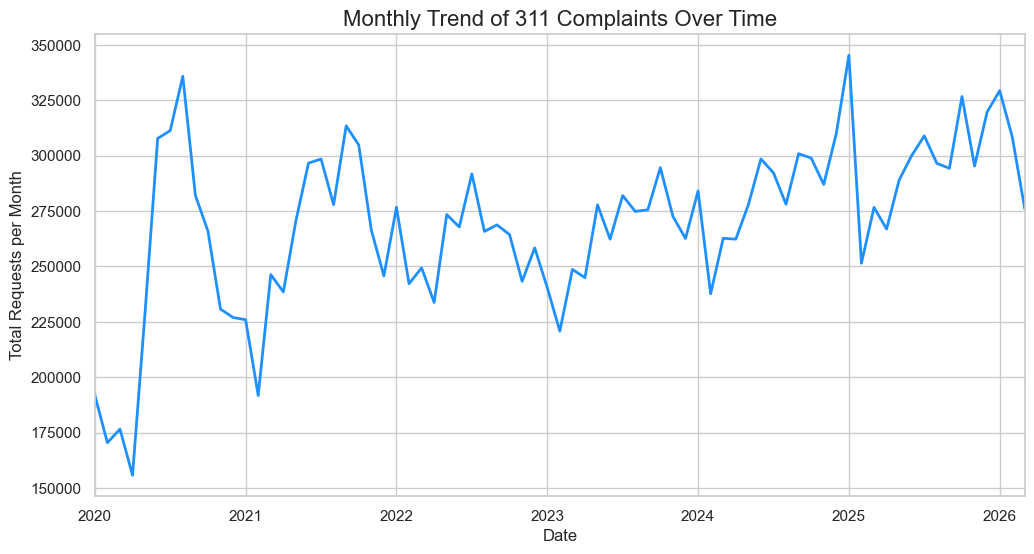

In [70]:
plt.figure(figsize=(12, 6))
dfTime = df.set_index('Created Date').resample('ME').size()
dfTime.plot(kind='line', color='dodgerblue', linewidth=2)
plt.title("Monthly Trend of 311 Complaints Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Requests per Month", fontsize=12)
plt.show()

- Caption

## Top Agencies Handling Requests ##

/var/folders/dr/l7061z6x155_nwbh9k4h_b4c0000gn/T/ipykernel_36721/1901911853.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topAgencies.index, y=topAgencies.values, palette="cubehelix")


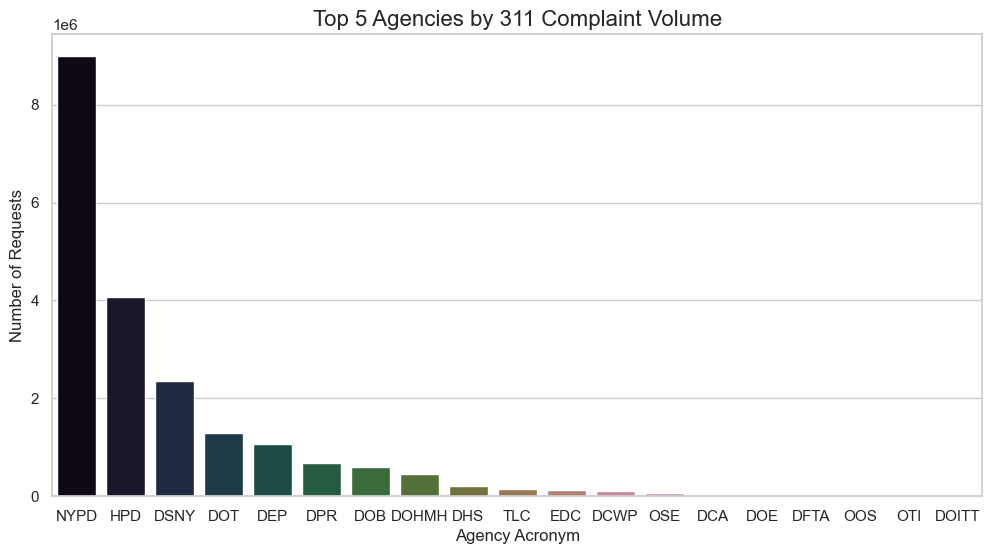

In [71]:
plt.figure(figsize=(12, 6))
topAgencies = df['Agency'].value_counts()
sns.barplot(x=topAgencies.index, y=topAgencies.values, palette="cubehelix")
plt.title("Top 5 Agencies by 311 Complaint Volume", fontsize=16)
plt.xlabel("Agency Acronym", fontsize=12)
plt.ylabel("Number of Requests", fontsize=12)
plt.show()

- Caption

## Distribution of Resolution Time for Top 10 Complaints ##

/var/folders/dr/l7061z6x155_nwbh9k4h_b4c0000gn/T/ipykernel_36721/3256019658.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_topClean, y='Problem (formerly Complaint Type)', x='LogResolutionTime', palette="Set2")


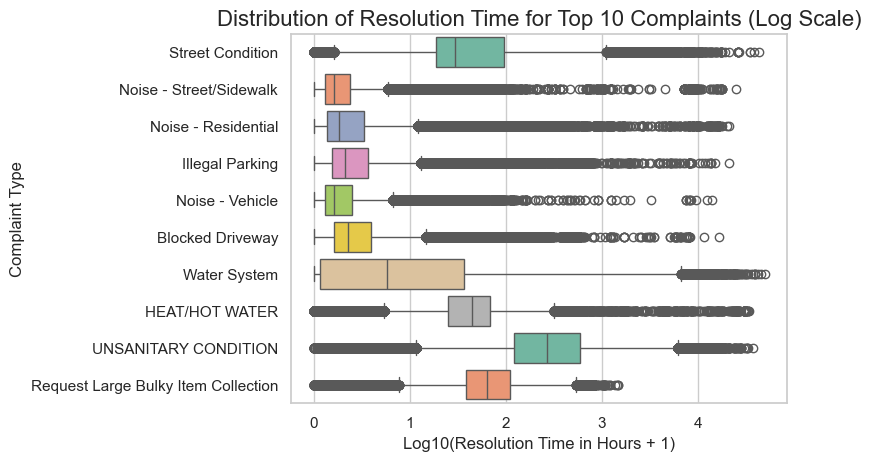

In [72]:
topComplaints = df['Problem (formerly Complaint Type)'].value_counts().head(10).index
df_top = df[df['Problem (formerly Complaint Type)'].isin(topComplaints)]

# Adding a small constant to avoid log(0) and dropping NaNs
df_topClean = df_top.dropna(subset=['ResolutionTimeHours']).copy()
df_topClean['LogResolutionTime'] = np.log10(df_topClean['ResolutionTimeHours'] + 1)

sns.boxplot(data=df_topClean, y='Problem (formerly Complaint Type)', x='LogResolutionTime', palette="Set2")
plt.title("Distribution of Resolution Time for Top 10 Complaints (Log Scale)", fontsize=16)
plt.xlabel("Log10(Resolution Time in Hours + 1)", fontsize=12)
plt.ylabel("Complaint Type", fontsize=12)
plt.show()

- Caption

## Heatmap of Top Complaints Across Boroughs ##

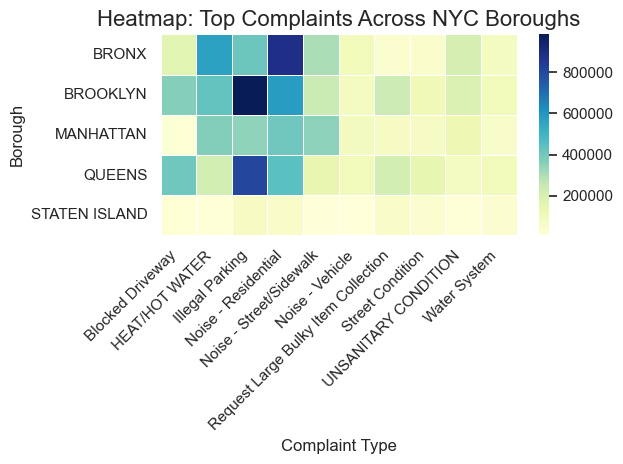

In [73]:
heatmapData = df_top.groupby(['Borough', 'Problem (formerly Complaint Type)']).size().unstack(fill_value=0)
sns.heatmap(heatmapData, annot=False, cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap: Top Complaints Across NYC Boroughs", fontsize=16)
plt.xlabel("Complaint Type", fontsize=12)
plt.ylabel("Borough", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Caption

## Summary of Initial Findings ##